# Smart Charging Using Reinforcement Learning

Approach for RL: an electric taxi is home from 2pm to 4pm each day. Every 15 minutes the charging agent picks a charging power (discrete levels between 0 and 22 kW). The battery can't exceed its capacity. When the taxi leaves at 4pm, a random energy demand for the day (D ~ N(30, 5) kWh) is drawn and must be covered by the battery, otherwise we pay a very high penalty. Charging cost grows with the square of the charging power. We model this as an MDP and solve it with Q-learning.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

## MDP Definition

- State s = (t, b): the current 15-minute timestep $t \in \{0, ..., 7\}$ (2pm to 4pm)
  and the current battery level b, discretized into bins so we can use a Q-table.
- Action a: one of 4 discrete charging power levels (zero / low / medium / high).
- Transition: battery increases by power * 0.25h, capped at battery capacity.
- Reward: negative charging cost each step (cost = coef * power^2). At the final step, we additionally subtract a large penalty if the battery is below the sampled demand.

**Assumptions** (chosen by ourselves):
- Battery capacity: 50 kWh
- Charging levels: 0, 7, 14, 22 kW
- Starting battery level at 2pm: random between 5 and 20 kWh (car arrives partially depleted)
- Cost coefficient: 0.05 per kW²

In [ ]:
# Environment settings
NUM_STEPS = 8                    # 15-min steps between 2pm and 4pm
STEP_HOURS = 0.25
BATTERY_CAPACITY = 50.0          # kWh
CHARGE_LEVELS = [0, 7, 14, 22]   # kW, discrete actions (zero/low/medium/high)
COST_COEF = 0.05                 # cost = COST_COEF * power_kw**2 per step
BATTERY_BIN_SIZE = 1.0           # kWh, for discretizing the state

DEMAND_MEAN = 30.0
DEMAND_STD = 5.0
OUT_OF_ENERGY_PENALTY = 1000.0

START_BATTERY_LOW = 5.0
START_BATTERY_HIGH = 20.0

## Environment

In [ ]:
# Simple discrete event simulation, following the same reset/step pattern used in the workshops

class SmartChargingEnv:
    def __init__(self):
        self.num_actions = len(CHARGE_LEVELS)

    def reset(self):
        self.t = 0
        self.battery = np.random.uniform(START_BATTERY_LOW, START_BATTERY_HIGH)
        return self._get_state()

    def _get_state(self):
        battery_bin = int(round(self.battery / BATTERY_BIN_SIZE))
        return (self.t, battery_bin)

    def step(self, action):
        power = CHARGE_LEVELS[action]
        energy_added = min(power * STEP_HOURS, BATTERY_CAPACITY - self.battery)
        actual_power = energy_added / STEP_HOURS
        cost = COST_COEF * actual_power ** 2

        self.battery += energy_added
        self.t += 1
        done = self.t == NUM_STEPS

        reward = -cost
        if done:
            demand = np.random.normal(DEMAND_MEAN, DEMAND_STD)
            if self.battery < demand:
                reward -= OUT_OF_ENERGY_PENALTY

        return self._get_state(), reward, done

In [ ]:
# Sanity check: one random episode
env = SmartChargingEnv()
state = env.reset()
done = False
print("start state:", state)

while not done:
    action = np.random.randint(env.num_actions)
    state, reward, done = env.step(action)
    print(f"action={CHARGE_LEVELS[action]}kW -> state={state}, reward={reward:.2f}")

start state: (0, 8)
action=7kW -> state=(1, 10), reward=-2.45
action=7kW -> state=(2, 11), reward=-2.45
action=14kW -> state=(3, 15), reward=-9.80
action=14kW -> state=(4, 18), reward=-9.80
action=22kW -> state=(5, 24), reward=-24.20
action=7kW -> state=(6, 26), reward=-2.45
action=0kW -> state=(7, 26), reward=-0.00
action=22kW -> state=(8, 31), reward=-24.20


## Q-Learning

In [ ]:
# Same off-policy TD control update as in the workshop

# Hyperparameters
num_episodes = 20_000
learning_rate = 0.1
gamma = 0.99
epsilon = 1.0
min_epsilon = 0.01
epsilon_decay = 0.9995

# Training
env = SmartChargingEnv()
Q = defaultdict(lambda: np.zeros(env.num_actions))
episode_rewards = []

for episode in range(num_episodes):
    state = env.reset()
    done = False
    total_reward = 0.0

    while not done:
        if np.random.random() < epsilon:
            action = np.random.randint(env.num_actions)
        else:
            action = np.argmax(Q[state])

        next_state, reward, done = env.step(action)
        total_reward += reward

        best_next_value = np.max(Q[next_state])
        Q[state][action] += learning_rate * (reward + gamma * best_next_value - Q[state][action])
        state = next_state

    episode_rewards.append(total_reward)
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

print("Training finished.")

Training finished.


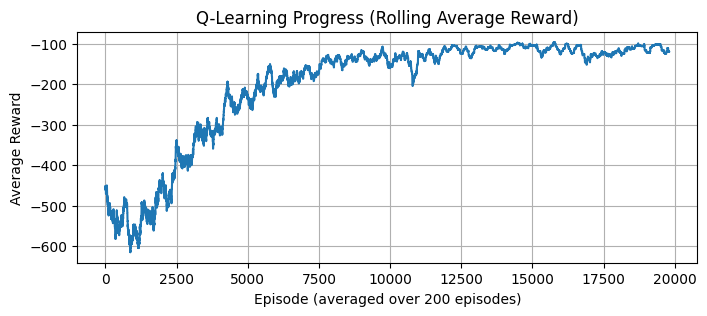

In [ ]:
# Learning progress (rolling average reward)
window_size = 200
rolling_avg = np.convolve(episode_rewards, np.ones(window_size) / window_size, mode="valid")

plt.figure(figsize=(8, 3))
plt.plot(rolling_avg)
plt.title("Q-Learning Progress (Rolling Average Reward)")
plt.xlabel(f"Episode (averaged over {window_size} episodes)")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()

## Evaluate learned policy

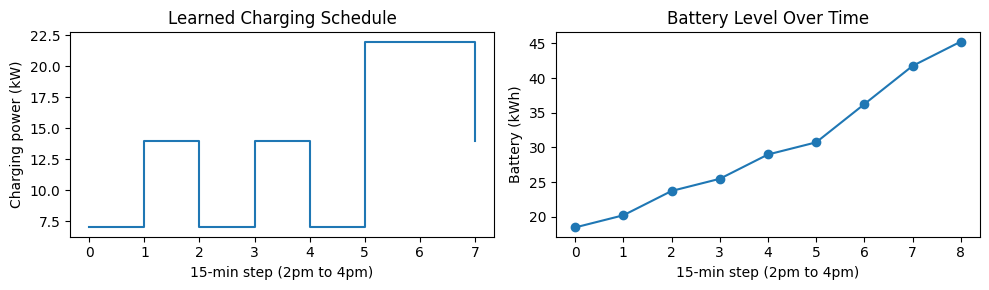

In [ ]:
# Run one episode greedily (no exploration) and inspect the charging schedule and battery trajectory.
state = env.reset()
done = False
battery_trace = [env.battery]
power_trace = []

while not done:
    action = np.argmax(Q[state])
    power_trace.append(CHARGE_LEVELS[action])
    state, reward, done = env.step(action)
    battery_trace.append(env.battery)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].step(range(NUM_STEPS), power_trace, where="post")
axes[0].set_title("Learned Charging Schedule")
axes[0].set_xlabel("15-min step (2pm to 4pm)")
axes[0].set_ylabel("Charging power (kW)")

axes[1].plot(range(NUM_STEPS + 1), battery_trace, marker="o")
axes[1].set_title("Battery Level Over Time")
axes[1].set_xlabel("15-min step (2pm to 4pm)")
axes[1].set_ylabel("Battery (kWh)")

plt.tight_layout()
plt.show()